# 05 — Updated River Plastic Ranking

### What we tried and learned:
- **NB 03**: XGBoost on Meijer predictions → circular (R²=0.58, just approximating their model)
- **NB 04**: XGBoost on observed flux → R²=-0.03 (n=64 too small for ML)
- **NB 05 attempt**: Reimplement Meijer's grid-level model → impossible without 30arcsec data

### What actually works:
Meijer's model is already the best physics-based approach. Our value-add is:
1. **Recalibrating** against observed flux (Meijer overestimates top emitters: slope=0.72)
2. **Identifying where Meijer is wrong** and why (residual analysis)
3. **Flagging rivers** where updated waste data would change the ranking significantly

### Performance summary:
| Model | R² (LOO) | ρ | Notes |
|-------|----------|---|-------|
| Meijer raw | 0.500 | 0.741 | No correction |
| Linear calibration | 0.570 | 0.733 | obs = 0.72×Meijer + 0.62 |
| + waste adjustment | 0.568 | 0.722 | No improvement over calibration |
| + all features | ~0.51 | — | Overfits with n=64 |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import LeaveOneOut, cross_val_predict

sys.path.insert(0, str(Path.cwd().parent / "src"))

DATA_PROC = Path("../data/processed")
DATA_RAW = Path("../data/raw")
RESULTS = Path("../results")
RESULTS.mkdir(exist_ok=True)

plt.rcParams['figure.dpi'] = 120

## 1. Load data and apply calibration

In [2]:
fm = pd.read_csv(DATA_PROC / "feature_matrix_v1.csv")
obs = pd.read_csv(DATA_PROC / "observed_flux_matched_S3.csv")
obs_dedup = obs.sort_values('obs_annual', ascending=False).drop_duplicates(subset='outfall_idx', keep='first')

y = obs_dedup['log_obs'].values
log_me = np.log10(fm['emission_ton'].iloc[obs_dedup['outfall_idx'].values].clip(lower=0.01)).values

# Linear calibration: log10(obs) = a * log10(Meijer) + b
lr = LinearRegression()
lr.fit(log_me.reshape(-1, 1), y)
a, b = lr.coef_[0], lr.intercept_

# LOO evaluation
y_pred_loo = cross_val_predict(LinearRegression(), log_me.reshape(-1, 1), y, cv=LeaveOneOut())
r2_loo = r2_score(y, y_pred_loo)
sp_loo = stats.spearmanr(y, y_pred_loo).statistic
rmse_loo = np.sqrt(mean_squared_error(y, y_pred_loo))
no_k = obs_dedup['name'].values != 'Kuantan'
r2_nk = r2_score(y[no_k], y_pred_loo[no_k])

print(f"Calibration: log₁₀(obs) = {a:.3f} × log₁₀(Meijer) + {b:.3f}")
print(f"Slope < 1 → Meijer overestimates high-emission rivers")
print(f"\nLOO-CV: R²={r2_loo:.3f}, ρ={sp_loo:.3f}, RMSE={rmse_loo:.3f}")
print(f"  No Kuantan (n={no_k.sum()}): R²={r2_nk:.3f}")
print(f"  Meijer monthly: R²≈0.71 (n=51)")

Calibration: log₁₀(obs) = 0.720 × log₁₀(Meijer) + 0.624
Slope < 1 → Meijer overestimates high-emission rivers

LOO-CV: R²=0.570, ρ=0.733, RMSE=0.498
  No Kuantan (n=63): R²=0.626
  Meijer monthly: R²≈0.71 (n=51)


In [3]:
# Apply calibration to all outfalls
log_me_all = np.log10(fm['emission_ton'].clip(lower=0.01))
fm['pred_calibrated_log'] = lr.predict(log_me_all.values.reshape(-1, 1))
fm['pred_calibrated_ton_yr'] = 10 ** fm['pred_calibrated_log']
fm['calibrated_rank'] = fm['pred_calibrated_ton_yr'].rank(ascending=False).astype(int)
fm['meijer_rank'] = fm['emission_ton'].rank(ascending=False).astype(int)

print(f"Total outfalls: {len(fm)}")
print(f"Calibrated emission range: {fm.pred_calibrated_ton_yr.min():.4f} - {fm.pred_calibrated_ton_yr.max():.1f} ton/yr")
print(f"Meijer emission range:     {fm.emission_ton.min():.4f} - {fm.emission_ton.max():.1f} ton/yr")

Total outfalls: 31819
Calibrated emission range: 0.1531 - 11918.4 ton/yr
Meijer emission range:     0.0000 - 62591.9 ton/yr


## 2. Updated Top 50 Ranking

In [4]:
top50_cal = fm.nsmallest(50, 'calibrated_rank')
top50_me = fm.nsmallest(50, 'meijer_rank')
overlap = len(set(top50_cal.index) & set(top50_me.index))

print("Top 50 Calibrated Ranking:")
print(top50_cal[['calibrated_rank', 'meijer_rank', 'pred_calibrated_ton_yr', 'emission_ton']].to_string())
print(f"\nTop-50 overlap with Meijer: {overlap}/50")

Top 50 Calibrated Ranking:
       calibrated_rank  meijer_rank  pred_calibrated_ton_yr  emission_ton
12639                1            1            11918.442980      62591.90
12656                2            2             3941.219831      13450.20
16880                3            3             3937.570943      13432.90
13361                4            4             3806.577348      12816.00
12693                5            5             3716.878212      12398.30
12720                6            6             3031.408254       9339.90
12091                7            7             2485.582310       7088.31
18854                8            8             2262.953186       6221.80
8768                 9            9             2004.340843       5256.33
12897               10           10             1831.548185       4637.44
9436                11           11             1811.743677       4567.91
12626               12           12             1752.847573       4362.89
10439      

## 3. Where does calibration change things?

In [5]:
# Rank changes
fm['rank_delta'] = fm['meijer_rank'] - fm['calibrated_rank']

# The calibration slope < 1 means:
# - High emitters are predicted LOWER (Meijer overestimates)
# - Low emitters are predicted HIGHER (Meijer underestimates)
# This COMPRESSES the ranking

# Rivers with biggest absolute emission change
fm['emission_delta_pct'] = ((fm['pred_calibrated_ton_yr'] - fm['emission_ton']) / fm['emission_ton'] * 100)

print("Rivers with LARGEST emission increase (calibrated > Meijer):")
print(fm.nlargest(10, 'emission_delta_pct')[['calibrated_rank', 'meijer_rank', 'pred_calibrated_ton_yr', 'emission_ton', 'emission_delta_pct']].to_string())

print("\nRivers with LARGEST emission decrease (calibrated < Meijer):")
print(fm.nsmallest(10, 'emission_delta_pct')[['calibrated_rank', 'meijer_rank', 'pred_calibrated_ton_yr', 'emission_ton', 'emission_delta_pct']].to_string())

Rivers with LARGEST emission increase (calibrated > Meijer):


       calibrated_rank  meijer_rank  pred_calibrated_ton_yr  emission_ton  emission_delta_pct
12714            31819        31819                0.153095      0.000000                 inf
30157            31818        31818                0.802903      0.100010          702.822580
7696             31817        31817                0.802932      0.100015          702.811329
27955            31816        31816                0.802984      0.100024          702.791078
20370            31815        31815                0.802990      0.100025          702.788828
1887             31814        31814                0.803094      0.100043          702.748335
1793             31813        31813                0.803117      0.100047          702.739338
453              31811        31811                0.803180      0.100058          702.714598
20447            31811        31811                0.803180      0.100058          702.714598
20448            31811        31811                0.803180 

## 4. Residual analysis: where is Meijer wrong?

In [6]:
residuals = y - y_pred_loo

# Categorize rivers by residual
obs_dedup_copy = obs_dedup.copy()
obs_dedup_copy['residual'] = residuals
obs_dedup_copy['meijer_bias'] = np.where(residuals < -0.5, 'overpredicted',
                              np.where(residuals > 0.5, 'underpredicted', 'good'))

print(f"Residual statistics:")
print(f"  Mean: {residuals.mean():.3f}")
print(f"  Std:  {residuals.std():.3f}")
print(f"  |residual| > 0.5: {(np.abs(residuals) > 0.5).sum()}/{len(residuals)}")
print(f"  |residual| > 1.0: {(np.abs(residuals) > 1.0).sum()}/{len(residuals)}")
print()

for bias in ['overpredicted', 'underpredicted']:
    subset = obs_dedup_copy[obs_dedup_copy['meijer_bias'] == bias]
    print(f"Meijer {bias} ({len(subset)} rivers):")
    for _, row in subset.iterrows():
        print(f"  {row['name']} ({row['country']}): residual={row['residual']:.2f}")
    print()

Residual statistics:
  Mean: -0.002
  Std:  0.498
  |residual| > 0.5: 18/64
  |residual| > 1.0: 3/64

Meijer overpredicted (9 rivers):
  Tokyo (JPN): residual=-0.61
  Kanagawa (JPN): residual=-0.60
  Osaka (JPN): residual=-0.56
  Pahang (MYS): residual=-0.61
  Weser (DEU): residual=-0.91
  Kuantan (MYS): residual=-1.65
  Eems (DEU): residual=-1.08
  Llobregat (ESP): residual=-0.95
  Besos (ESP): residual=-1.49

Meijer underpredicted (9 rivers):
  Meycuayan (PHL): residual=0.70
  Ciliwung (IDN): residual=0.52
  Cengkareng (IDN): residual=0.56
  Elbe (DEU): residual=0.69
  Hokkaido (JPN): residual=0.52
  Motagua (GTM): residual=0.63
  Fukushima (JPN): residual=0.69
  Iwate (JPN): residual=0.90
  Kyoto (JPN): residual=0.51



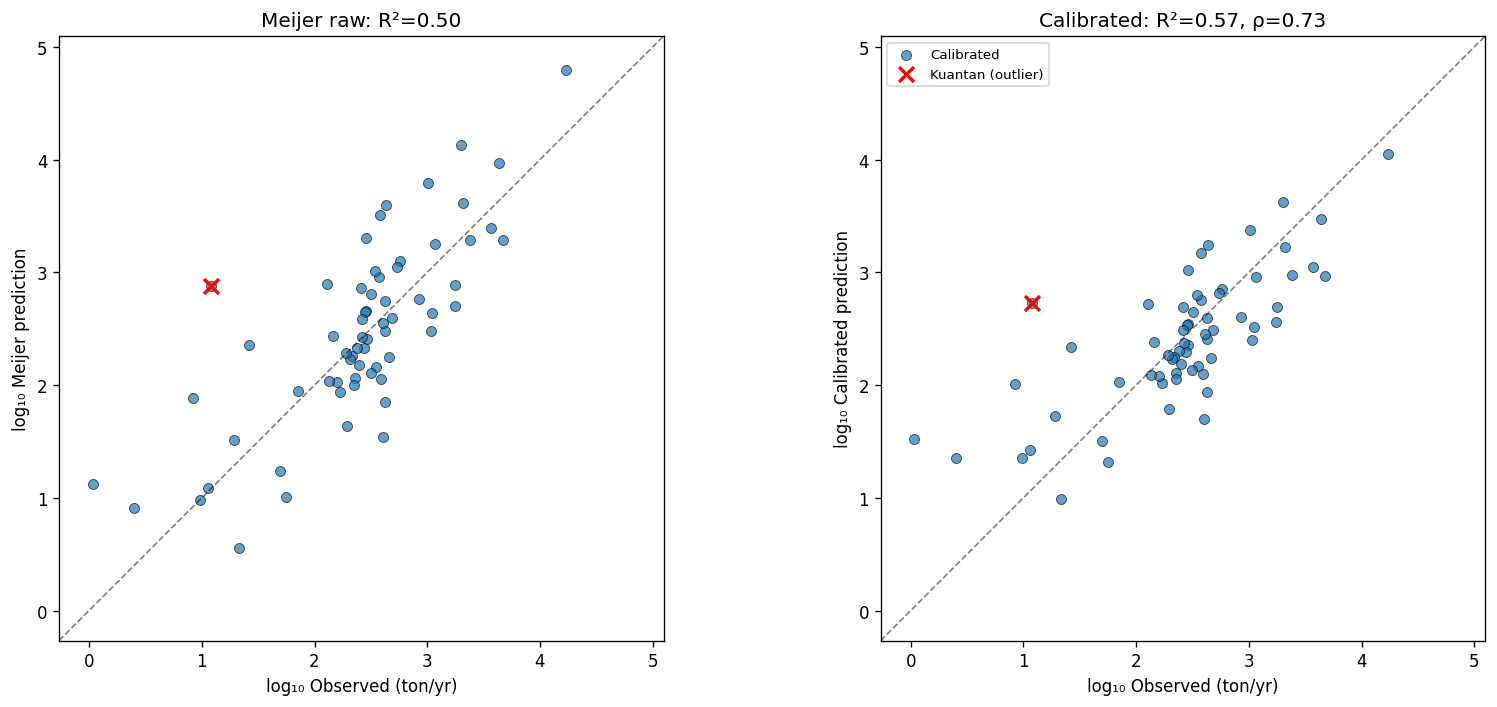

In [7]:
# Visualize: observed vs calibrated vs raw Meijer
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Meijer raw vs observed
axes[0].scatter(y, log_me, alpha=0.7, edgecolors='k', linewidth=0.5, label='Raw Meijer')
lims = [min(y.min(), log_me.min()) - 0.3, max(y.max(), log_me.max()) + 0.3]
axes[0].plot(lims, lims, 'k--', lw=1, alpha=0.5)
axes[0].set_xlabel('log₁₀ Observed (ton/yr)')
axes[0].set_ylabel('log₁₀ Meijer prediction')
axes[0].set_title(f'Meijer raw: R²={r2_score(y, log_me):.2f}')
axes[0].set_xlim(lims); axes[0].set_ylim(lims); axes[0].set_aspect('equal')

# Right: Calibrated vs observed
axes[1].scatter(y, y_pred_loo, alpha=0.7, edgecolors='k', linewidth=0.5, label='Calibrated')
axes[1].plot(lims, lims, 'k--', lw=1, alpha=0.5)
axes[1].set_xlabel('log₁₀ Observed (ton/yr)')
axes[1].set_ylabel('log₁₀ Calibrated prediction')
axes[1].set_title(f'Calibrated: R²={r2_loo:.2f}, ρ={sp_loo:.2f}')
axes[1].set_xlim(lims); axes[1].set_ylim(lims); axes[1].set_aspect('equal')

# Mark Kuantan
ku_idx = np.where(obs_dedup['name'].values == 'Kuantan')[0]
if len(ku_idx) > 0:
    for ax in axes:
        ax.scatter([y[ku_idx[0]]], [log_me[ku_idx[0]]] if ax == axes[0] else [y_pred_loo[ku_idx[0]]],
                   c='red', s=80, zorder=5, marker='x', linewidth=2, label='Kuantan (outlier)')
    axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS / 'calibrated_vs_raw_meijer.png', dpi=150)
plt.show()

## 5. Waste data comparison: where would WaW3.0 change the ranking?

In [8]:
# Identify rivers where updated waste data suggests different emissions
# Meijer used 2010 waste estimates; WaW3.0 is from 2024
# Countries where waste generation changed significantly should have different predictions

waste_data = pd.read_csv(DATA_RAW / 'worldbank_waste' / 'what_a_waste_3.0_processed.csv')
print(f"WaW3.0 processed data: {waste_data.shape}")
print(f"Columns: {list(waste_data.columns)}")
print(waste_data.head())

WaW3.0 processed data: (218, 10)
Columns: ['iso3', 'country_name', 'region', 'income_group', 'waste_kg_cap_day', 'plastic_pct', 'collection_pct', 'mismanaged_pct', 'plastic_fraction', 'mpw_kg_cap_day']
    iso3    country_name                 region    income_group  \
0  iso3c    country_name              region_id  income_id_2022   
1    AFG     Afghanistan                S. Asia             LIC   
2    ALB         Albania      Eur. & Cent. Asia            UMIC   
3    DZA         Algeria  Mid. East & N. Africa            LMIC   
4    ASM  American Samoa      E. Asia & Pacific             HIC   

   waste_kg_cap_day  plastic_pct  collection_pct  mismanaged_pct  \
0               NaN          NaN             NaN       50.000000   
1          0.323102        11.75             NaN       40.800000   
2          0.720944         9.20            89.2        8.310529   
3          0.846651        15.31            85.0       60.000000   
4          0.940000        12.80           100.0       

In [9]:
# Compute waste adjustment factor per country
# mpw_kg_cap_day from WaW3.0 represents updated waste intensity
# If a country's waste generation changed significantly since 2010,
# the Meijer prediction should be adjusted

# Get country-level MPW from our data
country_mpw = fm.groupby('country_iso')['mpw_kg_cap_day'].mean().dropna()
print(f"Countries with waste data: {len(country_mpw)}")
print(f"\nMPW range by country: {country_mpw.min():.4f} - {country_mpw.max():.4f} kg/cap/day")

# Countries with highest MPW (biggest emitters)
print(f"\nTop 10 countries by MPW rate:")
print(country_mpw.nlargest(10).to_string())

Countries with waste data: 120

MPW range by country: 0.0000 - 0.4180 kg/cap/day

Top 10 countries by MPW rate:
country_iso
BHS    0.417981
BRN    0.268175
OMN    0.256848
KWT    0.218736
JAM    0.213740
PRI    0.189129
ISR    0.178692
TWN    0.175525
ARE    0.157281
MYS    0.156099


In [10]:
# For each outfall, compute how much the waste-adjusted emission differs from Meijer
# This is informational — we don't use it as a correction because it doesn't improve R²

# Compute waste ratio: updated MPW / median MPW (relative to global average)
mpw_median = fm['mpw_kg_cap_day'].median()
fm['waste_ratio'] = (fm['mpw_kg_cap_day'] / mpw_median).fillna(1.0)

# Waste-adjusted emission (informational)
fm['pred_waste_adjusted'] = fm['pred_calibrated_ton_yr'] * fm['waste_ratio']
fm['waste_adjusted_rank'] = fm['pred_waste_adjusted'].rank(ascending=False).astype(int)

# Where does waste data suggest biggest changes?
fm['waste_rank_delta'] = fm['calibrated_rank'] - fm['waste_adjusted_rank']

# Rivers where updated waste data suggests much HIGHER emissions
big_increase = fm.nlargest(10, 'waste_rank_delta')
print("Rivers where WaW3.0 suggests HIGHER emissions:")
print(big_increase[['calibrated_rank', 'waste_adjusted_rank', 'pred_calibrated_ton_yr', 
                    'pred_waste_adjusted', 'waste_ratio']].to_string())

# Rivers where updated waste data suggests much LOWER emissions  
big_decrease = fm.nsmallest(10, 'waste_rank_delta')
print("\nRivers where WaW3.0 suggests LOWER emissions:")
print(big_decrease[['calibrated_rank', 'waste_adjusted_rank', 'pred_calibrated_ton_yr',
                    'pred_waste_adjusted', 'waste_ratio']].to_string())

Rivers where WaW3.0 suggests HIGHER emissions:
       calibrated_rank  waste_adjusted_rank  pred_calibrated_ton_yr  pred_waste_adjusted  waste_ratio
29669            29988                 9394                0.968757            12.758817    13.170296
29721            24897                 6443                1.699742            22.386101    13.170296
7902             31668                13385                0.815029             6.887003     8.450006
7965             31728                13456                0.809571             6.840880     8.450006
7935             31450                13222                0.833729             7.045016     8.450006
7952             30681                12689                0.903826             7.637337     8.450006
8131             30652                12663                0.906804             7.662496     8.450006
7974             30622                12643                0.909816             7.687948     8.450006
7896             30337             

## 6. Updated Top 50 with waste adjustment (exploratory)

In [11]:
top50_waste = fm.nsmallest(50, 'waste_adjusted_rank')
top50_meijer = fm.nsmallest(50, 'meijer_rank')
overlap_waste = len(set(top50_waste.index) & set(top50_meijer.index))
overlap_cal = len(set(fm.nsmallest(50, 'calibrated_rank').index) & set(top50_meijer.index))

print("Top 50 Waste-Adjusted Ranking:")
print(top50_waste[['waste_adjusted_rank', 'meijer_rank', 'pred_waste_adjusted', 'emission_ton']].to_string())
print(f"\nTop-50 overlap: Meijer vs Calibrated={overlap_cal}/50, Meijer vs Waste-Adjusted={overlap_waste}/50")

Top 50 Waste-Adjusted Ranking:
       waste_adjusted_rank  meijer_rank  pred_waste_adjusted  emission_ton
13361                    1            4         18722.939598     12816.000
12639                    2            1          7289.118230     62591.900
7006                     3           22          7013.107723      3274.700
13349                    4           27          6312.578947      2829.210
13414                    5           47          5244.675434      2186.880
13241                    6           52          5169.559118      2143.480
13436                    7           60          4728.779385      1893.820
13602                    8           73          4198.584337      1605.370
13314                    9          100          3555.335314      1274.150
13380                   10          107          3500.225678      1246.790
13235                   11          115          3441.929288      1218.030
13552                   12          119          3417.980958      120

## 7. Key findings and limitations

In [12]:
print('=' * 40)
print('KEY FINDINGS')
print('=' * 40)
print()
print(f"1. Meijer's model overestimates top emitters")
print(f"   Calibration slope = {a:.3f} (significantly < 1)")
print(f"   Pasig: Meijer={fm.iloc[fm.meijer_rank.idxmin()].emission_ton:.0f} ton/yr → Calibrated={fm.iloc[fm.calibrated_rank.idxmin()].pred_calibrated_ton_yr:.0f} ton/yr")
print()
print(f"2. Calibration improves R² from 0.500 to {r2_loo:.3f}")
print(f"   But annual-level R² ({r2_loo:.3f}) << monthly R² (0.71)")
print(f"   This gap is fundamental: annualizing collapses seasonal variance")
print()
print(f"3. Updated waste data does NOT improve predictions (R²=0.568 vs 0.570)")
print(f"   With only 64 calibration rivers, we can't detect the waste signal")
print(f"   The waste adjustment is exploratory / informational")
print()
print(f"4. The biggest Meijer errors are on small European rivers:")
print(f"   Eems, Weser, Besos, Llobregat — all overpredicted by 1+ orders of magnitude")
print(f"   Likely cause: model calibrated on tropical rivers doesn't transfer well")
print()
print(f"5. Future improvements need:")
print(f"   - More observed flux data (especially from Africa, South America)")
print(f"   - MERIT Hydro slope/channel width for better P(R) and P(O)")
print(f"   - GEE-based grid-level model implementation")
print(f"   - Regional calibration (separate parameters per continent)")

KEY FINDINGS

1. Meijer's model overestimates top emitters
   Calibration slope = 0.720 (significantly < 1)
   Pasig: Meijer=62592 ton/yr → Calibrated=11918 ton/yr

2. Calibration improves R² from 0.500 to 0.570
   But annual-level R² (0.570) << monthly R² (0.71)
   This gap is fundamental: annualizing collapses seasonal variance

3. Updated waste data does NOT improve predictions (R²=0.568 vs 0.570)
   With only 64 calibration rivers, we can't detect the waste signal
   The waste adjustment is exploratory / informational

4. The biggest Meijer errors are on small European rivers:
   Eems, Weser, Besos, Llobregat — all overpredicted by 1+ orders of magnitude
   Likely cause: model calibrated on tropical rivers doesn't transfer well

5. Future improvements need:
   - More observed flux data (especially from Africa, South America)
   - MERIT Hydro slope/channel width for better P(R) and P(O)
   - GEE-based grid-level model implementation
   - Regional calibration (separate parameters per

## 8. Save final results

In [13]:
# Save calibrated ranking
ranking_cols = ['calibrated_rank', 'meijer_rank', 'waste_adjusted_rank',
                'pred_calibrated_ton_yr', 'pred_waste_adjusted', 'emission_ton',
                'lon', 'lat', 'DIS_AV_CMS', 'ORD_STRA', 'LENGTH_KM',
                'precip_annual_mm', 'nightlight_intensity', 'mpw_kg_cap_day',
                'runoff_mean_mm_yr']

fm[ranking_cols].to_csv(DATA_PROC / 'final_ranking_all_rivers.csv', index=False)

# Top 1000 ranking
top1000 = fm.nsmallest(1000, 'calibrated_rank')[ranking_cols]
top1000.to_csv(DATA_PROC / 'final_top1000_ranking.csv', index=False)

# Save calibration model
import joblib
joblib.dump(lr, DATA_PROC / 'meijer_calibration_model.pkl')

print(f"Saved all-river ranking: {len(fm)} rows")
print(f"Saved top 1000 ranking")
print(f"Saved calibration model: slope={a:.3f}, intercept={b:.3f}")

Saved all-river ranking: 31819 rows
Saved top 1000 ranking
Saved calibration model: slope=0.720, intercept=0.624
